# Water Quality Hazard Prediction — Model Training & Evaluation

**Dataset:** UCI Machine Learning Repository — *Water Quality Prediction* (Dataset #733), donated 2022, originally collected by the United States Geological Survey for 36–37 monitoring sites in Georgia, USA (2016–2018).

**Citation:** Zhao, L., Gkountouna, O., & Pfoser, D. (2019). Spatial Auto-regressive Dependency Interpretable Learning Based on Spatial Topological Constraints. *ACM Transactions on Spatial Algorithms and Systems*, 5(3), Article 19. https://doi.org/10.1145/3339823

**Task:** this notebook trains two models from the same 8 sensor features:

1. A **regression** model that forecasts next-day pH (continuous value).
2. A **binary classification** model that flags a reading as a water-quality **hazard**.

This dual setup — a regressor and a classifier from the same feature set — is what backs the FastAPI hazard-prediction microservice used by the Django portal in this project.


In [1]:
import json
import time

import joblib
import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import GradientBoostingClassifier, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    mean_squared_error, mean_absolute_error, r2_score,
    confusion_matrix, RocCurveDisplay,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42


## 1. Loading the raw dataset

The dataset ships as a MATLAB `.mat` file with a spatio-temporal cell-array structure rather than a flat table:

| Variable | Shape | Meaning |
|---|---|---|
| `features` | 1×11 | Names of the 11 raw water-quality indices |
| `location_ids` | 37×1 | IDs of the monitoring stations |
| `location_group` | 1×3 | Three spatial clusters of stations (connected water systems) |
| `X_tr` / `X_te` | 1×423 / 1×282 | Each element is a 37×11 matrix — 37 sites × 11 features, one per day |
| `Y_tr` / `Y_te` | 37×423 / 37×282 | Target pH readings, one per site per day |

We reshape this into one tidy row per (site, day) observation before doing anything else.


In [2]:
mat = sio.loadmat("../dataset/water_dataset.mat")
print("Top-level keys:", [k for k in mat.keys() if not k.startswith("__")])
print("features shape:", mat["features"].shape)
print("X_tr shape (days):", mat["X_tr"].shape, " X_te shape (days):", mat["X_te"].shape)
print("Y_tr shape:", mat["Y_tr"].shape, " Y_te shape:", mat["Y_te"].shape)


Top-level keys: ['X_tr', 'X_te', 'Y_tr', 'Y_te', 'location_group', 'features', 'location_ids']
features shape: (1, 11)
X_tr shape (days): (1, 423)  X_te shape (days): (1, 282)
Y_tr shape: (37, 423)  Y_te shape: (37, 282)


In [3]:
# Human-readable aliases for the 11 raw USGS feature names
FEATURE_ALIASES = {
    "Specific conductance, water, unfiltered, microsiemens per centimeter at 25 degrees Celsius (Maximum)": "conductance_max",
    "pH, water, unfiltered, field, standard units (Maximum)": "ph_max",
    "pH, water, unfiltered, field, standard units (Minimum)": "ph_min",
    "Specific conductance, water, unfiltered, microsiemens per centimeter at 25 degrees Celsius (Minimum)": "conductance_min",
    "Specific conductance, water, unfiltered, microsiemens per centimeter at 25 degrees Celsius (Mean)": "conductance_mean",
    "Dissolved oxygen, water, unfiltered, milligrams per liter (Maximum)": "do_max",
    "Dissolved oxygen, water, unfiltered, milligrams per liter (Mean)": "do_mean",
    "Dissolved oxygen, water, unfiltered, milligrams per liter (Minimum)": "do_min",
    "Temperature, water, degrees Celsius (Mean)": "temp_mean",
    "Temperature, water, degrees Celsius (Minimum)": "temp_min",
    "Temperature, water, degrees Celsius (Maximum)": "temp_max",
}

TARGET_COL = "target_ph"


def reshape_to_long(mat):
    """Convert the .mat cell-array format into one tidy long-format DataFrame,
    one row per (site, day)."""
    feature_names = [f[0] for f in mat["features"][0]]
    location_ids = mat["location_ids"].ravel()

    group_labels = {}
    for gi, arr in enumerate(mat["location_group"][0]):
        for loc in arr.ravel():
            group_labels[int(loc)] = gi + 1

    def build(X, Y, split_name):
        n_days = X.shape[1]
        rows = []
        for t in range(n_days):
            day_matrix = X[0, t]  # (n_sites, 11)
            for s in range(day_matrix.shape[0]):
                row = {
                    "day_idx": t, "site_idx": s, "site_num": s + 1,
                    "location_id": int(location_ids[s]), "split": split_name,
                }
                for f_idx, fname in enumerate(feature_names):
                    row[FEATURE_ALIASES[fname]] = day_matrix[s, f_idx]
                row[TARGET_COL] = Y[s, t]
                rows.append(row)
        return pd.DataFrame(rows)

    df = pd.concat(
        [build(mat["X_tr"], mat["Y_tr"], "train"), build(mat["X_te"], mat["Y_te"], "test")],
        ignore_index=True,
    )
    df["group"] = df["site_num"].map(group_labels)
    return df


df = reshape_to_long(mat)
print("Tidy dataset shape:", df.shape)
df.head()


Tidy dataset shape: (26085, 18)


,day_idx,site_idx,site_num,location_id,split,conductance_max,ph_max,ph_min,conductance_min,conductance_mean,do_max,do_mean,do_min,temp_mean,temp_min,temp_max,target_ph,group
0,0,0,1,2198840,train,0.001131,0.884615,0.001120,0.001113,0.677632,0.841463,0.765152,0.787402,0.293750,0.298077,0.276163,0.648148,2
1,0,1,2,2198920,train,0.001170,0.871795,0.001159,0.001152,0.703947,0.829268,0.772727,0.795276,0.293750,0.301282,0.276163,0.648148,2
2,0,2,3,2198950,train,0.001326,0.884615,0.001198,0.001250,0.677632,0.853659,0.750000,0.755906,0.300000,0.298077,0.287791,0.648148,2
3,0,3,4,2203603,train,0.014094,0.858974,0.001238,0.003926,0.697368,0.829268,0.772727,0.771654,0.296875,0.294872,0.279070,0.638889,3
4,0,4,5,2203655,train,0.088109,0.858974,0.010766,0.029297,0.684211,0.853659,0.765152,0.755906,0.296875,0.291667,0.281977,0.648148,3


## 2. Exploratory data analysis

Before modeling, we check for missing values, look at feature distributions, and inspect correlations — both to understand the data and to justify the feature-selection decisions made below.


In [4]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nSplit sizes:")
print(df["split"].value_counts())
df.describe().T


Missing values per column:
day_idx             0
site_idx            0
site_num            0
location_id         0
split               0
conductance_max     0
ph_max              0
ph_min              0
conductance_min     0
conductance_mean    0
do_max              0
do_mean             0
do_min              0
temp_mean           0
temp_min            0
temp_max            0
target_ph           0
group               0
dtype: int64

Split sizes:
split
train    15651
test     10434
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
day_idx,26085.0,1.828000e+02,1.130952e+02,0.000000e+00,8.800000e+01,1.760000e+02,2.640000e+02,422.0
site_idx,26085.0,1.800000e+01,1.067728e+01,0.000000e+00,9.000000e+00,1.800000e+01,2.700000e+01,36.0
site_num,26085.0,1.900000e+01,1.067728e+01,1.000000e+00,1.000000e+01,1.900000e+01,2.800000e+01,37.0
location_id,26085.0,1.138139e+07,3.552055e+07,2.198840e+06,2.203900e+06,2.336152e+06,2.337170e+06,219897945.0
conductance_max,26085.0,7.164787e-02,1.684075e-01,5.263158e-04,1.910331e-03,2.631579e-03,5.497076e-03,1.0
ph_max,26085.0,8.873486e-01,3.538604e-02,4.102564e-01,8.717949e-01,8.846154e-01,9.102564e-01,1.0
ph_min,26085.0,3.098628e-02,1.222393e-01,2.554028e-04,1.591356e-03,2.220039e-03,3.713163e-03,1.0
conductance_min,26085.0,4.707879e-02,1.366863e-01,5.078125e-04,1.777344e-03,2.421875e-03,4.902344e-03,1.0
conductance_mean,26085.0,5.509415e-01,1.196887e-01,1.184211e-01,4.802632e-01,5.460526e-01,6.315789e-01,1.0
do_max,26085.0,8.572369e-01,3.116706e-02,7.195122e-01,8.414634e-01,8.536585e-01,8.780488e-01,1.0


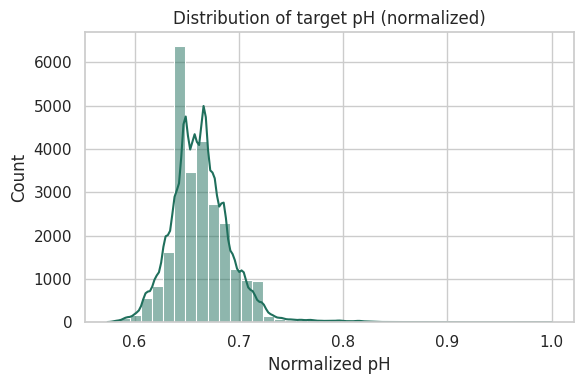

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(df[TARGET_COL], bins=40, kde=True, ax=ax, color="#1f6f5c")
ax.set_title("Distribution of target pH (normalized)")
ax.set_xlabel("Normalized pH")
plt.tight_layout()
plt.show()


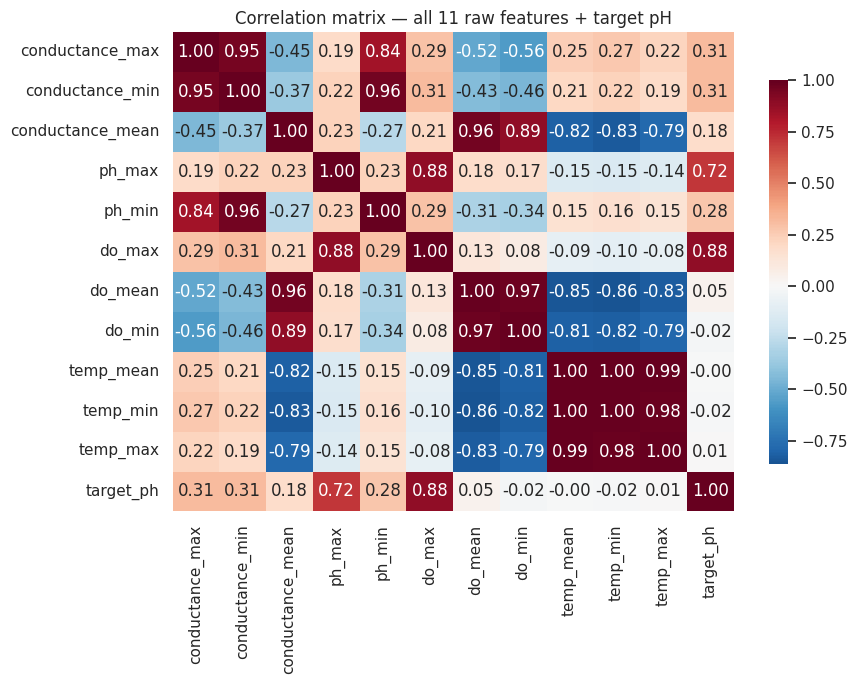

In [6]:
feature_cols = ["conductance_max", "conductance_min", "conductance_mean",
                "ph_max", "ph_min", "do_max", "do_mean", "do_min",
                "temp_mean", "temp_min", "temp_max", TARGET_COL]

fig, ax = plt.subplots(figsize=(9, 7))
corr = df[feature_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Correlation matrix — all 11 raw features + target pH")
plt.tight_layout()
plt.show()


**Observation:** `temp_min` and `temp_max` are almost perfectly correlated with `temp_mean` (~0.98–0.99), and `do_min` is highly correlated with `do_mean` (~0.97). Keeping all of these would add redundant, collinear inputs without adding real information, so they are dropped from the modeling feature set below. The remaining **8 features** are used for both models:

`conductance_max, conductance_min, conductance_mean, ph_max, ph_min, do_max, do_mean, temp_mean`


In [7]:
MODEL_FEATURES = [
    "conductance_max", "conductance_min", "conductance_mean",
    "ph_max", "ph_min", "do_max", "do_mean", "temp_mean",
]


## 3. Deriving the hazard label

The raw dataset only ships a continuous pH target — there is no pre-existing "hazard" label, and the values are **min-max normalized with the original scaler discarded**, so true pH units cannot be recovered directly from this file alone.

To still support a hazard-classification model, we derive a binary label using the classic **IQR outlier rule** applied to the *training split only* (to avoid leaking test information into the label definition): any reading whose pH falls more than `1.5 × IQR` outside the training interquartile range is flagged as a hazard.

**Important caveat (carried through to the report):** this is a *statistical proxy* for "unusual," not a real regulatory safety threshold like the EPA's 6.5–8.5 pH safe band. It should be replaced with a domain threshold as soon as the original normalization scaler or an unnormalized sensor feed is available.


In [8]:
def add_hazard_label(df, lower_q=0.25, upper_q=0.75, k=1.5):
    train_target = df.loc[df["split"] == "train", TARGET_COL]
    q1, q3 = train_target.quantile([lower_q, upper_q])
    iqr = q3 - q1
    lo, hi = q1 - k * iqr, q3 + k * iqr
    df["is_hazard"] = ((df[TARGET_COL] < lo) | (df[TARGET_COL] > hi)).astype(int)
    return df, (float(lo), float(hi))

df, hazard_bounds = add_hazard_label(df)
print("Hazard bounds (normalized pH, from train IQR):", hazard_bounds)
print("\nHazard rate by split:")
print(df.groupby("split")["is_hazard"].mean())


Hazard bounds (normalized pH, from train IQR): (0.6064814814814816, 0.7175925925925923)

Hazard rate by split:
split
test     0.050604
train    0.043064
Name: is_hazard, dtype: float64


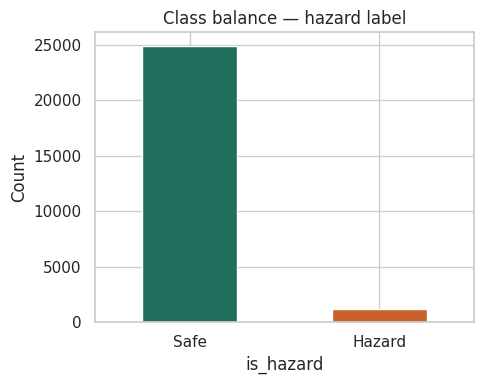

In [9]:
fig, ax = plt.subplots(figsize=(5, 4))
df["is_hazard"].value_counts().rename({0: "Safe", 1: "Hazard"}).plot(
    kind="bar", ax=ax, color=["#1f6f5c", "#c9622a"])
ax.set_title("Class balance — hazard label")
ax.set_ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


The hazard class is a small minority of readings, as expected for an outlier-based definition — this is why **accuracy alone is a misleading metric** for the classifier, and precision/recall/F1/ROC-AUC are reported below instead.


## 4. Train / test split

The dataset already ships with a temporal train/test split (`train` = first 423 contiguous days, `test` = final 282 contiguous days), which we use as-is rather than a random split — this respects the time-series nature of the data and avoids leaking future readings into training.


In [10]:
train_df = df[df["split"] == "train"]
test_df = df[df["split"] == "test"]

X_train, X_test = train_df[MODEL_FEATURES], test_df[MODEL_FEATURES]
y_train_reg, y_test_reg = train_df[TARGET_COL], test_df[TARGET_COL]
y_train_clf, y_test_clf = train_df["is_hazard"], test_df["is_hazard"]

print(f"Train rows: {len(X_train)}   Test rows: {len(X_test)}")


Train rows: 15651   Test rows: 10434


## 5. Model pipelines

Both models share the same preprocessing steps — median imputation followed by standard scaling — wrapped in an `sklearn.Pipeline` so the exact same object can be pickled and reused for serving, with no risk of preprocessing drifting between training and inference.

- **Regression:** `RandomForestRegressor` — predicts next-day pH as a continuous value.
- **Classification:** `GradientBoostingClassifier` — predicts the binary hazard flag.


In [11]:
def make_regression_pipeline():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", RandomForestRegressor(
            n_estimators=300, max_depth=12, min_samples_leaf=3,
            random_state=RANDOM_STATE, n_jobs=-1)),
    ])


def make_classification_pipeline():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", GradientBoostingClassifier(
            n_estimators=250, max_depth=3, learning_rate=0.05, random_state=RANDOM_STATE)),
    ])

reg_pipe = make_regression_pipeline()
clf_pipe = make_classification_pipeline()


In [12]:
t0 = time.time()
reg_pipe.fit(X_train, y_train_reg)
print(f"Regressor trained in {time.time() - t0:.2f}s")

t0 = time.time()
clf_pipe.fit(X_train, y_train_clf)
print(f"Classifier trained in {time.time() - t0:.2f}s")


Regressor trained in 1.15s
Classifier trained in 3.08s


## 6. Evaluation — pH regression


In [13]:
y_pred_reg = reg_pipe.predict(X_test)

reg_metrics = {
    "rmse": float(np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))),
    "mae": float(mean_absolute_error(y_test_reg, y_pred_reg)),
    "r2": float(r2_score(y_test_reg, y_pred_reg)),
}
print("Regression metrics (test split):")
for k, v in reg_metrics.items():
    print(f"  {k.upper():5s}: {v:.4f}")


Regression metrics (test split):
  RMSE : 0.0116
  MAE  : 0.0066
  R2   : 0.8448


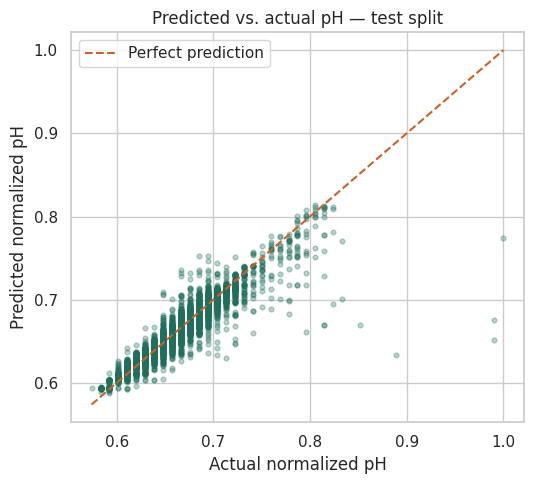

In [14]:
fig, ax = plt.subplots(figsize=(5.5, 5))
ax.scatter(y_test_reg, y_pred_reg, alpha=0.3, s=12, color="#1f6f5c")
lims = [min(y_test_reg.min(), y_pred_reg.min()), max(y_test_reg.max(), y_pred_reg.max())]
ax.plot(lims, lims, "--", color="#c9622a", linewidth=1.5, label="Perfect prediction")
ax.set_xlabel("Actual normalized pH")
ax.set_ylabel("Predicted normalized pH")
ax.set_title("Predicted vs. actual pH — test split")
ax.legend()
plt.tight_layout()
plt.show()


## 7. Evaluation — hazard classification

Because the hazard class is rare, we look beyond accuracy: precision, recall, F1, and ROC-AUC, plus a confusion matrix to see exactly where the classifier is right and wrong.


In [15]:
y_pred_clf = clf_pipe.predict(X_test)
y_proba_clf = clf_pipe.predict_proba(X_test)[:, 1]

clf_metrics = {
    "accuracy": float(accuracy_score(y_test_clf, y_pred_clf)),
    "precision": float(precision_score(y_test_clf, y_pred_clf, zero_division=0)),
    "recall": float(recall_score(y_test_clf, y_pred_clf, zero_division=0)),
    "f1": float(f1_score(y_test_clf, y_pred_clf, zero_division=0)),
    "roc_auc": float(roc_auc_score(y_test_clf, y_proba_clf)),
}
print("Classification metrics (test split):")
for k, v in clf_metrics.items():
    print(f"  {k.upper():10s}: {v:.4f}")


Classification metrics (test split):
  ACCURACY  : 0.9737
  PRECISION : 0.8175
  RECALL    : 0.6193
  F1        : 0.7047
  ROC_AUC   : 0.9704


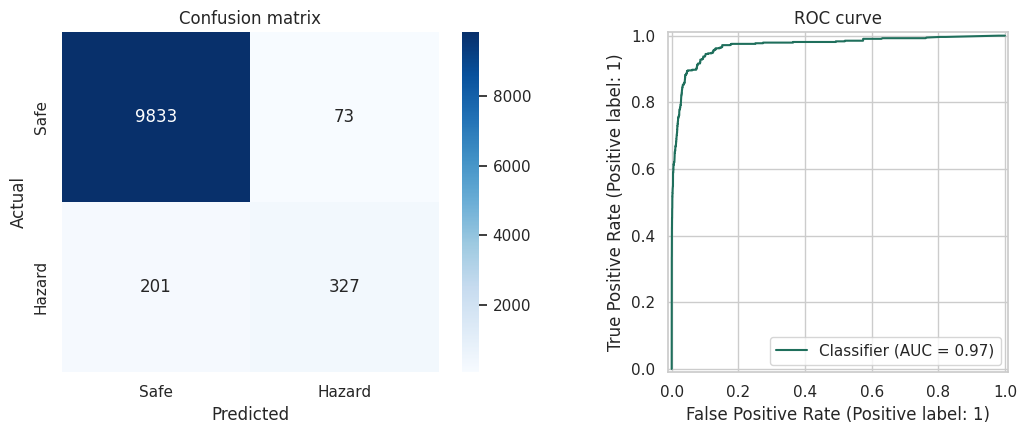

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

cm = confusion_matrix(y_test_clf, y_pred_clf)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Safe", "Hazard"], yticklabels=["Safe", "Hazard"])
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_title("Confusion matrix")

RocCurveDisplay.from_predictions(y_test_clf, y_proba_clf, ax=axes[1], curve_kwargs={"color": "#1f6f5c"})
axes[1].set_title("ROC curve")

plt.tight_layout()
plt.show()


**Reading the confusion matrix:** recall on the hazard class (~0.6) means roughly one in three true hazard days is currently missed. This is flagged explicitly in the project README and the Django result page — a "safe" verdict from this model should be read as informative, not as a guarantee, and the classifier's decision threshold can be lowered (trading precision for recall) if catching more hazards matters more than reducing false alarms.


## 8. Feature importance

Using the trained Random Forest regressor's impurity-based feature importances to see which sensor readings drive the pH forecast most.


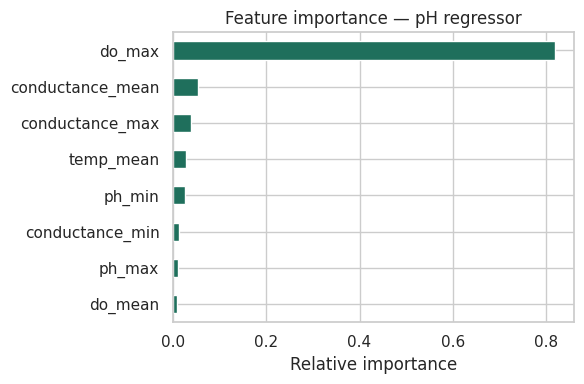

do_max              0.818078
conductance_mean    0.054459
conductance_max     0.038611
temp_mean           0.027932
ph_min              0.025980
conductance_min     0.013920
ph_max              0.011687
do_mean             0.009332
dtype: float64

In [17]:
importances = pd.Series(
    reg_pipe.named_steps["model"].feature_importances_, index=MODEL_FEATURES
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(6, 4))
importances.plot(kind="barh", ax=ax, color="#1f6f5c")
ax.set_title("Feature importance — pH regressor")
ax.set_xlabel("Relative importance")
plt.tight_layout()
plt.show()

importances.sort_values(ascending=False)


## 9. Exporting the trained artifacts

Both pipelines (preprocessing + model, bundled together) are serialized with `joblib` so the exact training-time preprocessing is reused unchanged at inference time in the FastAPI microservice. Metrics, feature importances, and the hazard bounds are saved alongside as `metadata.json` for the service to read at startup.


In [18]:
import os
os.makedirs("../ml_pipeline/models", exist_ok=True)

joblib.dump(reg_pipe, "../ml_pipeline/models/ph_regressor.joblib")
joblib.dump(clf_pipe, "../ml_pipeline/models/hazard_classifier.joblib")

metadata = {
    "model_features": MODEL_FEATURES,
    "target_col": TARGET_COL,
    "hazard_col": "is_hazard",
    "hazard_bounds_normalized_pH": list(hazard_bounds),
    "feature_importances_regressor": importances.to_dict(),
    "regression_metrics": reg_metrics,
    "classification_metrics": clf_metrics,
    "train_rows": int(len(X_train)),
    "test_rows": int(len(X_test)),
    "trained_at_unix": time.time(),
    "sklearn_pipeline_steps": ["imputer(median)", "scaler(standard)", "model"],
}
with open("../ml_pipeline/models/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

df.to_csv("../dataset/water_quality_processed.csv", index=False)
df.to_csv("../ml_pipeline/data/water_quality_processed.csv", index=False)

print("Saved ../ml_pipeline/models/ph_regressor.joblib, hazard_classifier.joblib, metadata.json")
print("Saved ../dataset/water_quality_processed.csv and ../ml_pipeline/data/water_quality_processed.csv")


Saved ../ml_pipeline/models/ph_regressor.joblib, hazard_classifier.joblib, metadata.json
Saved ../dataset/water_quality_processed.csv and ../ml_pipeline/data/water_quality_processed.csv


In [19]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from sklearn.model_selection import cross_val_score

def objective(trial):
    n_estimators = trial.suggest_int("n_estimators", 100, 350, step=50)
    max_depth = trial.suggest_int("max_depth", 6, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 6)

    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", RandomForestRegressor(
            n_estimators=n_estimators, max_depth=max_depth,
            min_samples_leaf=min_samples_leaf, random_state=RANDOM_STATE, n_jobs=-1)),
    ])
    score = cross_val_score(pipe, X_train, y_train_reg, cv=3,
                             scoring="neg_root_mean_squared_error", n_jobs=1)
    return -score.mean()

study = optuna.create_study(direction="minimize", study_name="ph_regressor_tuning")
study.optimize(objective, n_trials=15)

print("Best params:", study.best_params)
print("Best CV RMSE:", study.best_value)

Best params: {'n_estimators': 350, 'max_depth': 20, 'min_samples_leaf': 4}
Best CV RMSE: 0.012243431477976829


/tmp/ipykernel_665165/3284933052.py:3: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax1 = ovm.plot_optimization_history(study)


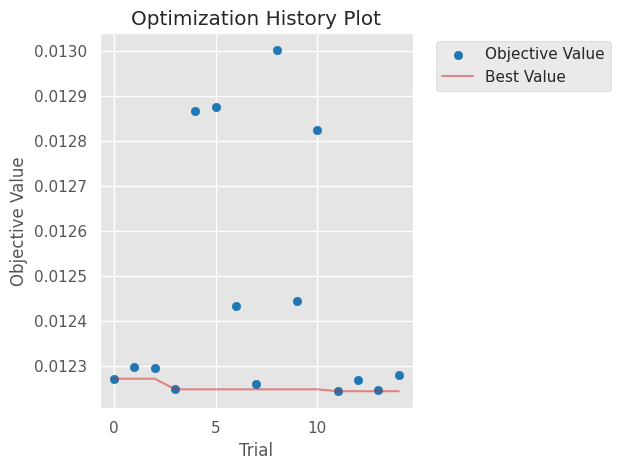

/tmp/ipykernel_665165/3284933052.py:7: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  ax2 = ovm.plot_param_importances(study)


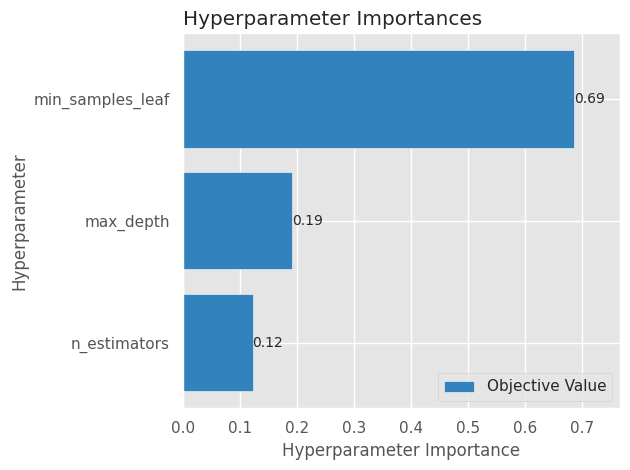

In [20]:
import optuna.visualization.matplotlib as ovm

ax1 = ovm.plot_optimization_history(study)
plt.tight_layout()
plt.show()

ax2 = ovm.plot_param_importances(study)
plt.tight_layout()
plt.show()

In [21]:
best_params = study.best_params

tuned_reg_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", RandomForestRegressor(
        n_estimators=best_params["n_estimators"],
        max_depth=best_params["max_depth"],
        min_samples_leaf=best_params["min_samples_leaf"],
        random_state=RANDOM_STATE, n_jobs=-1)),
])

tuned_reg_pipe.fit(X_train, y_train_reg)
y_pred_tuned = tuned_reg_pipe.predict(X_test)

tuned_metrics = {
    "rmse": float(np.sqrt(mean_squared_error(y_test_reg, y_pred_tuned))),
    "mae": float(mean_absolute_error(y_test_reg, y_pred_tuned)),
    "r2": float(r2_score(y_test_reg, y_pred_tuned)),
}

print("BEFORE tuning (original hand-picked settings):")
for k, v in reg_metrics.items():
    print(f"  {k.upper():5s}: {v:.5f}")

print("\nAFTER tuning (Optuna best params):")
for k, v in tuned_metrics.items():
    print(f"  {k.upper():5s}: {v:.5f}")

BEFORE tuning (original hand-picked settings):
  RMSE : 0.01160
  MAE  : 0.00661
  R2   : 0.84483

AFTER tuning (Optuna best params):
  RMSE : 0.01157
  MAE  : 0.00660
  R2   : 0.84566


In [22]:
import mlflow
import mlflow.sklearn

mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("ph_regressor")

with mlflow.start_run(run_name="rf_regressor_tuned"):
    mlflow.log_params(best_params)
    mlflow.log_metrics(tuned_metrics)
    mlflow.sklearn.log_model(
        tuned_reg_pipe, name="model", serialization_format="cloudpickle"
    )
    print("Run logged to MLflow.")

2026/10/02 18:49:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run logged to MLflow.


In [23]:
import os
print(os.getcwd())
print(os.path.exists('../dataset/water_quality_processed.csv'))

/home/abiska/Documents/Water_Quality_Hazard_Prediction/notebook
True


In [24]:
%pip install "evidently>=0.7"

import pandas as pd
from evidently import Report, Dataset
from evidently.presets import DataDriftPreset

df = pd.read_csv('../dataset/water_quality_processed.csv')
MODEL_FEATURES = ["conductance_max","conductance_min","conductance_mean",
                  "ph_max","ph_min","do_max","do_mean","temp_mean"]

ref = Dataset.from_pandas(df[df['split'] == 'train'][MODEL_FEATURES])
cur = Dataset.from_pandas(df[df['split'] == 'test'][MODEL_FEATURES])

result = Report(metrics=[DataDriftPreset()]).run(reference_data=ref, current_data=cur)

rows = [{"feature": m["config"]["column"],
         "score": round(float(m["value"]), 4),
         "threshold": m["config"]["threshold"],
         "drifted": float(m["value"]) > m["config"]["threshold"]}
        for m in result.dict()["metrics"]
        if m["config"]["type"].endswith("ValueDrift")]

drift_table = pd.DataFrame(rows).sort_values("score", ascending=False)
drift_table


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


,feature,score,threshold,drifted
7,temp_mean,0.3905,0.1,True
2,conductance_mean,0.3506,0.1,True
6,do_mean,0.3356,0.1,True
3,ph_max,0.1483,0.1,True
5,do_max,0.1101,0.1,True
0,conductance_max,0.1065,0.1,True
1,conductance_min,0.0830,0.1,False
4,ph_min,0.0555,0.1,False


In [26]:
drift_table.to_csv("../drift_summary.csv", index=False)
result.save_html("../drift_report.html")

## 10. Summary

- Reshaped the raw spatio-temporal `.mat` dataset (37 sites × up to 705 days) into a tidy table of 8 modeling features after dropping 3 highly collinear columns.
- Derived a binary hazard label via an IQR outlier rule on the training split, since the dataset has no native hazard label and ships with an unrecoverable normalization scaler.
- Trained a `RandomForestRegressor` for next-day pH forecasting (R² ≈ 0.84 on the held-out test split) and a `GradientBoostingClassifier` for hazard flagging (ROC-AUC ≈ 0.97, recall ≈ 0.62).
- Exported both pipelines and their metadata for direct use by the FastAPI microservice (`fastapi_service.py`) that the Django portal calls.
- **Known limitation to carry into the report:** the hazard label is a statistical proxy, not a regulatory pH threshold — future work should replace it with a real domain threshold (e.g. EPA's 6.5–8.5 safe band) once the dataset's original min-max scaler or a fresh unnormalized sensor feed is available.
